In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import netcdf
import netCDF4 as nc
# fname 为 你下载的字体库路径，注意 SourceHanSansSC-Bold.otf 字体的路径
import matplotlib
zhfont1 = matplotlib.font_manager.FontProperties(fname=r"/home/zhangzhibo/font/SourceHanSansSC-Bold.otf") 


In [4]:
file_path_base = r'/home/zhangzhibo/serghei/serghei-gw-transport-ing/test/t6/'
subsurface_file_path = file_path_base + r'out-333/output_subsurface.nc'
subsurface_dataset =  nc.Dataset(subsurface_file_path, 'r') # 'r' 表示只读模式
wc_out = subsurface_dataset.variables['wc'][:]
h_out = subsurface_dataset.variables['hd'][:]
qx_out = subsurface_dataset.variables['qx'][:]
qy_out = subsurface_dataset.variables['qy'][:]
qz_out = subsurface_dataset.variables['qz'][:]
subsurface_dataset

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(73), x(40), y(1), z(20)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 hd(t, z, y, x), float64 wc(t, z, y, x), float64 qx(t, z, y, x), float64 qy(t, z, y, x), float64 qz(t, z, y, x)
    groups: 

In [5]:
tt = 60
L = 10
H = 5
dz = 0.25
dim = [40, 1, 20]
N = int(dim[0]*dim[1]*dim[2])

In [6]:
h_out1 = []
wc_out = []
h_out1.append(h_out[:,:,0,:])
wt_out = []
x = np.linspace(0, L, dim[0])
ioutput = 0



In [7]:
serghei = h_out[-1,:,0,:]

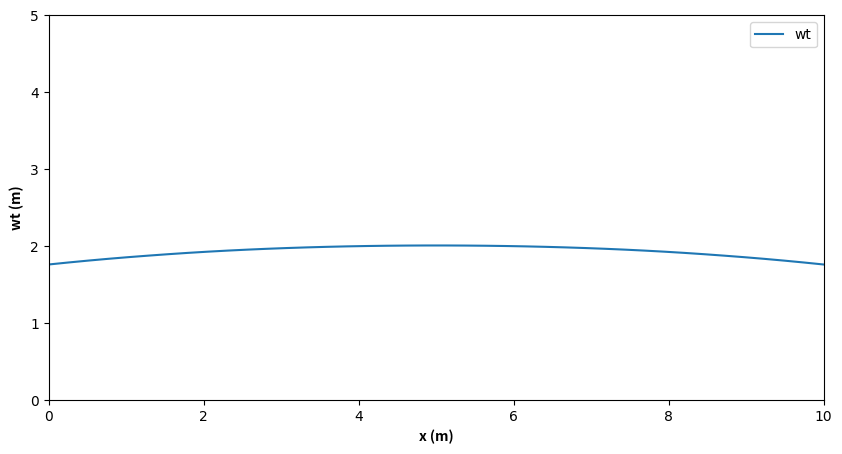

In [8]:
wt = np.zeros((dim[0]))
for ii in range(dim[0]):
	for kk in range(dim[2]-1):
		h1 = serghei[kk,ii]
		h2 = serghei[kk+1,ii]
		z1 = H - (kk+0.5)*dz
		z2 = H - (kk+1.5)*dz
		if h1 < 0.0 and h2 >= 0:
		    wt[ii] = z1 - h1*(z1-z2)/(h1-h2)
        # break
wt_out.append(wt)
plt.figure(figsize=(10, 5))
plt.plot(x, wt_out[ioutput], label='wt')
plt.xlabel('x (m)', fontproperties=zhfont1)
plt.ylabel('wt (m)', fontproperties=zhfont1)
plt.ylim(0, 5)
plt.xlim(0, 10)
plt.legend()
plt.show()

In [1]:
# 设置列数
num_columns = 400

# 生成一行400个0的字符串
row = ' '.join(['0'] * num_columns)

# 将字符串写入TXT文件
with open('output.txt', 'w') as file:
    file.write(row + '\n')  # 写入行并添加换行符

In [2]:
import numpy as np

# 设置等差数列的参数
start = -0.375
end = 1.625
num_rows = 200

# 生成等差数列，确保长度为 num_rows
arange = np.linspace(start, end, num_rows)

# 将等差数列扩展为 200 行 400 列的矩阵，每列数值相同
matrix = np.tile(arange, (400, 1)).T  # .T 转置以匹配列数

# 将矩阵保存到 TXT 文件
np.savetxt("matrix.txt", matrix, fmt="%.3f", delimiter=" ")
# 提取第一列并保存到另一个 TXT 文件
first_column = matrix[:, 0]
np.savetxt("first_column.txt", first_column, fmt="%.3f", delimiter="\n")